# Telco Customer Churn: PyCaret vs. scikit-learn

**Asignatura:** Ciencia de Datos  
**Integrantes:** David Célleri, José Solórzano

## 1. Descarga del dataset

Dataset: **Telco Customer Churn (IBM Sample Data)**, publicado en Kaggle:
<https://www.kaggle.com/datasets/blastchar/telco-customer-churn>.

Se descarga con `kagglehub`. Si Kaggle no está disponible (sin conexión o sin credenciales),
se usa como respaldo la copia publicada por IBM en GitHub. El CSV se guarda en `data/`.

In [1]:
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import shutil
import urllib.request
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CSV_PATH = DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

KAGGLE_DATASET = "blastchar/telco-customer-churn"
FALLBACK_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

if CSV_PATH.exists():
    print(f"El dataset ya existe en {CSV_PATH}")
else:
    try:
        import kagglehub

        download_dir = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        shutil.copy(next(download_dir.glob("*.csv")), CSV_PATH)
        print(f"Descargado desde Kaggle en {CSV_PATH}")
    except Exception as e:
        print(f"No se pudo descargar desde Kaggle ({e}); usando respaldo de IBM")
        urllib.request.urlretrieve(FALLBACK_URL, CSV_PATH)
        print(f"Descargado desde GitHub (IBM) en {CSV_PATH}")

print(f"Tamaño: {CSV_PATH.stat().st_size / 1024:.1f} KB")

/home/david_c/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargado desde Kaggle en data/WA_Fn-UseC_-Telco-Customer-Churn.csv
Tamaño: 954.6 KB


## 2. Análisis inicial de los datos

Se revisa la estructura del dataset, los tipos de datos, la calidad (faltantes, duplicados,
valores inconsistentes) y la relación de las variables con el objetivo `Churn`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)

# Paleta: azul = permanece (No), naranja = abandona (Yes)
COLOR_NO, COLOR_YES = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "axes.axisbelow": True,
})

df = pd.read_csv(CSV_PATH)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 7,043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Tipos de datos y valores únicos

In [4]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(),
    "ejemplos": [df[c].unique()[:4].tolist() for c in df.columns],
})
resumen

,tipo,nulos,unicos,ejemplos
customerID,str,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,str,0,2,"[Female, Male]"
SeniorCitizen,int64,0,2,"[0, 1]"
Partner,str,0,2,"[Yes, No]"
Dependents,str,0,2,"[No, Yes]"
tenure,int64,0,73,"[1, 34, 2, 45]"
PhoneService,str,0,2,"[No, Yes]"
MultipleLines,str,0,3,"[No phone service, No, Yes]"
InternetService,str,0,3,"[DSL, Fiber optic, No]"
OnlineSecurity,str,0,3,"[No, Yes, No internet service]"


`TotalCharges` debería ser numérica pero se leyó como texto, y `SeniorCitizen` es categórica
aunque está codificada como 0/1. Se revisa por qué `TotalCharges` no es numérica.

In [5]:
total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
no_numericos = df[total_num.isna()]
print(f"Valores no numéricos en TotalCharges: {len(no_numericos)}")
print(f"Valores distintos: {no_numericos['TotalCharges'].unique().tolist()}")
no_numericos[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Valores no numéricos en TotalCharges: 11
Valores distintos: [' ']


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Los 11 valores problemáticos son cadenas en blanco y corresponden a clientes con `tenure = 0`,
es decir, clientes recién incorporados a los que aún no se les ha facturado. No son datos
perdidos al azar: el cargo total real es 0.

### 2.2 Duplicados

In [6]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")
print(f"Filas duplicadas ignorando customerID: {df.drop(columns='customerID').duplicated().sum()}")

Filas duplicadas: 0
customerID duplicados: 0
Filas duplicadas ignorando customerID: 22


No hay registros repetidos. Las filas idénticas sin `customerID` son clientes distintos con el
mismo perfil (combinaciones comunes de servicios y cargos), por lo que se conservan.

### 2.3 Variable objetivo

       clientes  porcentaje
Churn                      
No         5174        73.5
Yes        1869        26.5


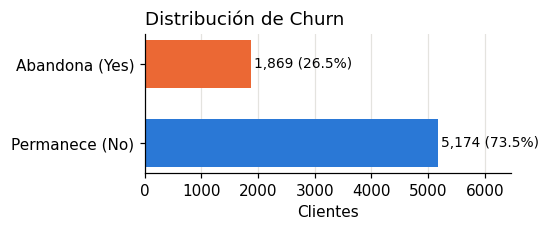

In [7]:
churn = df["Churn"].value_counts()
print(pd.DataFrame({"clientes": churn, "porcentaje": (churn / len(df) * 100).round(1)}))

fig, ax = plt.subplots(figsize=(5, 2.2))
ax.barh(["Permanece (No)", "Abandona (Yes)"], [churn["No"], churn["Yes"]],
        color=[COLOR_NO, COLOR_YES], height=0.6)
for i, v in enumerate([churn["No"], churn["Yes"]]):
    ax.text(v + 60, i, f"{v:,} ({v / len(df):.1%})", va="center", fontsize=9)
ax.set_xlabel("Clientes")
ax.set_title("Distribución de Churn", loc="left")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, churn.max() * 1.25)
plt.tight_layout()
plt.show()

El dataset está **desbalanceado** (~73% / 27%). Por eso la propuesta mide AUC-ROC, F1 y recall de
la clase "abandona" en lugar de solo accuracy, y conviene usar particiones estratificadas.

### 2.4 Variables numéricas

In [8]:
df_num = df.assign(TotalCharges=total_num)
numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
df_num[numericas].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


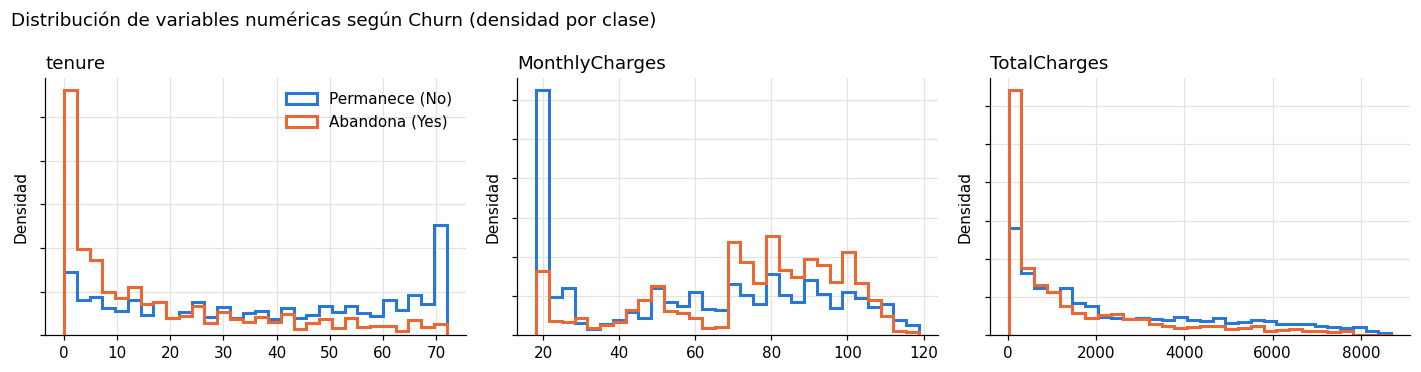

Medianas por clase:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.43,1683.60
Yes,10.0,79.65,703.55


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, numericas):
    datos = df_num[col].dropna()
    bins = 30
    rango = (datos.min(), datos.max())
    # Densidad para comparar la forma de ambas clases pese al desbalance
    for clase, color, etiqueta in [("No", COLOR_NO, "Permanece (No)"), ("Yes", COLOR_YES, "Abandona (Yes)")]:
        ax.hist(df_num.loc[df_num["Churn"] == clase, col].dropna(), bins=bins, range=rango,
                density=True, histtype="step", linewidth=2, color=color, label=etiqueta)
    ax.set_title(col, loc="left")
    ax.set_ylabel("Densidad")
    ax.set_yticklabels([])
axes[0].legend(frameon=False)
fig.suptitle("Distribución de variables numéricas según Churn (densidad por clase)", x=0.01, ha="left")
plt.tight_layout()
plt.show()

print("Medianas por clase:")
df_num.groupby("Churn")[numericas].median().round(2)

In [10]:
print("Correlación entre variables numéricas:")
df_num[numericas].corr().round(2)

Correlación entre variables numéricas:


,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


- Los clientes que abandonan tienen **antigüedad (`tenure`) mucho menor** y **cargos mensuales más altos**.
- `TotalCharges` está fuertemente correlacionada con `tenure` (≈ producto de antigüedad y cargo
  mensual), así que aporta información en gran parte redundante.
- No se observan valores atípicos imposibles (cargos negativos o antigüedades fuera de rango).

### 2.5 Variables categóricas: tasa de abandono por categoría

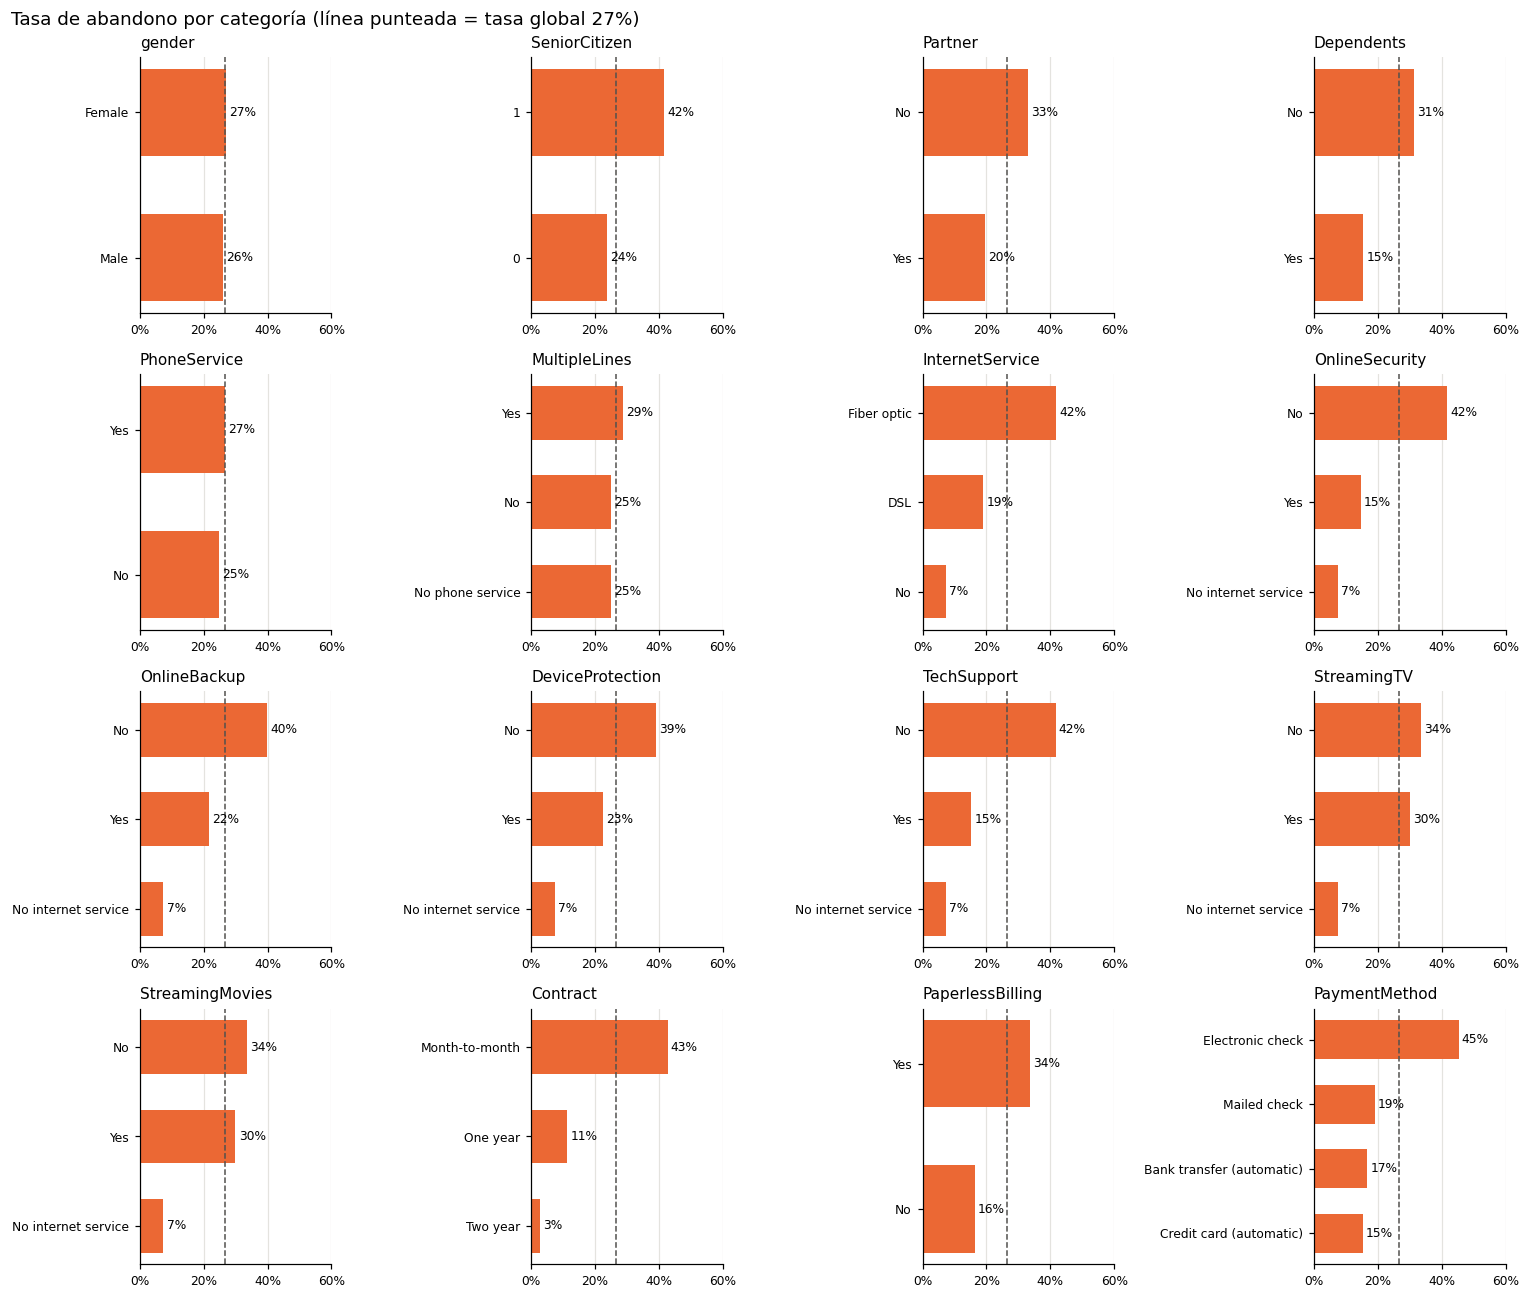

In [11]:
categoricas = [c for c in df.columns
               if c not in numericas + ["customerID", "Churn"]]

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
tasa_global = (df["Churn"] == "Yes").mean()
for ax, col in zip(axes.flat, categoricas):
    tasa = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values()
    ax.barh(tasa.index.astype(str), tasa.values, color=COLOR_YES, height=0.6)
    ax.axvline(tasa_global, color="#52514e", linestyle="--", linewidth=1)
    for i, v in enumerate(tasa.values):
        ax.text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=8)
    ax.set_title(col, loc="left", fontsize=10)
    ax.set_xlim(0, 0.6)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", visible=False)
for ax in axes.flat[len(categoricas):]:
    ax.axis("off")
fig.suptitle(f"Tasa de abandono por categoría (línea punteada = tasa global {tasa_global:.0%})",
             x=0.01, ha="left")
plt.tight_layout()
plt.show()

Observaciones principales:

- **Contract**: los contratos mes a mes concentran el abandono; los de dos años casi no abandonan.
- **InternetService**: fibra óptica tiene una tasa de abandono claramente mayor que DSL.
- **PaymentMethod**: el cheque electrónico destaca frente a los pagos automáticos.
- Servicios de soporte (`OnlineSecurity`, `TechSupport`) se asocian con menor abandono.
- **SeniorCitizen**, sin pareja (`Partner`) o sin dependientes y con `PaperlessBilling` abandonan más.
- `gender` y `PhoneService` prácticamente no diferencian entre clases.
- La categoría "No internet service" / "No phone service" repite la información de
  `InternetService` / `PhoneService`; se mantiene porque es una categoría válida y el
  *one-hot encoding* la trata sin problema.

## 3. Limpieza de datos

Decisiones tomadas a partir del análisis:

1. **`TotalCharges`**: convertir a numérica; los 11 valores en blanco (clientes con `tenure = 0`)
   se reemplazan por **0**, que es su valor real, en lugar de eliminarlos o imputarlos con una estadística.
2. **`customerID`**: se elimina; es un identificador sin valor predictivo.
3. **`SeniorCitizen`**: se recodifica de 0/1 a "No"/"Yes" para tratarla como categórica, igual que el resto.
4. **`Churn`**: se codifica como 1 (abandona) / 0 (permanece) para que ambos enfoques usen la misma etiqueta positiva.
5. **Duplicados**: no se eliminan (son clientes distintos).

La imputación, codificación y escalado propios del modelado quedan para cada enfoque
(PyCaret y scikit-learn), de modo que ambos partan del mismo dataset limpio.

In [12]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"].str.strip(), errors="coerce")
df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"] = (
    df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"].fillna(0.0)
)

df_clean = df_clean.drop(columns="customerID")
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1}).astype(int)

df_clean.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

### 3.1 Verificación

In [13]:
assert df_clean.isna().sum().sum() == 0, "Quedan valores faltantes"
assert df_clean["TotalCharges"].dtype == "float64"
assert set(df_clean["Churn"].unique()) == {0, 1}
assert len(df_clean) == len(df)

print(f"Dimensiones: {df_clean.shape}")
print(f"Valores faltantes: {df_clean.isna().sum().sum()}")
print(f"Tasa de abandono: {df_clean['Churn'].mean():.2%}")
df_clean.describe(include="all").T

Dimensiones: (7043, 20)
Valores faltantes: 0
Tasa de abandono: 26.54%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Guardar el dataset limpio

In [14]:
CLEAN_PATH = DATA_DIR / "telco_churn_clean.csv"
df_clean.to_csv(CLEAN_PATH, index=False)
print(f"Dataset limpio guardado en {CLEAN_PATH} ({df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas)")

Dataset limpio guardado en data/telco_churn_clean.csv (7,043 filas × 20 columnas)
